##National Grid Demand Forecasting

**Business Problem.** 
UK's electricity grid runs on a constraint: demand and supply have to match almost exactly in real time. So if the National Grid Electricity System Operator gets its demand wrong, it either has too much electricity generation, which result in demand that is difficult to store, that does not meet the requirement. Due to these issues, a balancing costs get passed down through electricity bills, so a more accurate day ahead forecast isn't an operational nicety, it's a direct lever on cost and grid reliability.

**What this project set to do**
The goal was to built a next day demand forecasting model that meaningfully beats that naive "tomorrow equal today" baseline by using real historical grid data, generation mix and calendar features rather than assuming any one modeling approach would obviously work. Because the grid underlying pattern have shifted so much over that period, so the data was deliberately filtered to a more recent window to avoid training on outdated relationships that no longer reflect how the grid behave today.

Three recurrent neural network architectures (SimpleRNN, LSTM, and GRU) were trained and compared under identical, controlled conditions, since the real test of isn't whether one model produce a good looking number, its whether its fairly compared against alternatives and against the baseline it is supposed to beat. The GRU model came out ahead, reaching an R2 of about 0.86 against a persistence baseline of 0.78, large enough gap picking up on genuine demand dynamics, not just echoing yesterday's readings.

**Why this matter**

A model like this, if it were deployed rather than kept as a research exercise, would feed directly into how much generation capacity gets scheduled a day ahead. Even a small , consistent improvement in forecasting accuracy at national grid scale translate into real money saved in balancing costs and a smoother path to integrating more intermittent renewable generation without compromising reliability.


**ML Formulation** time series regression problem - using the most recent 24 hours (48 half hourly data points) of demand, generation mix, and calendar information, forecast the country's demand for the next 48 half hours. 
** Data Source.** [National Grid Energy Consumption 2009-2025]
(https://www.kaggle.com/datasets/tomfarnell/national-grid-energy-consumption-2009-2025).

## Loading Libraries


In [70]:
import pandas as pd
import numpy as np
import tensorflow as tf
import sklearn.preprocessing
import sklearn.metrics
import plotly.graph_objects as go
from IPython.display import Image

##Loading the dataset

In [71]:
df=pd.read_csv(r"C:\Users\ragha\Downloads\new neural\National Grid Data 2009-2025.csv",skiprows=3,low_memory=False)
df.head()

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
0,01/01/2025,1,21036,26215,19918,5405,6606,0,18720,0,...,-1518,-1026,1,-232,-386,-558.0,96.0,0.0,241.0,0.0
1,01/01/2025,2,21222,26063,20167,5358,6606,0,18720,0,...,-1513,-1023,1,-124,-282,-564.0,51.0,0.0,262.0,0.0
2,01/01/2025,3,21385,25734,20328,5237,6606,0,18720,0,...,-1428,-922,1,-119,-384,-205.0,62.0,0.0,414.0,0.0
3,01/01/2025,4,20473,24988,19460,5115,6606,0,18720,0,...,-1423,-915,0,-119,-334,-193.0,37.0,0.0,423.0,0.0
4,01/01/2025,5,19634,24912,18654,5080,6606,0,18720,0,...,-1539,-899,0,-119,-363,-622.0,-282.0,0.0,288.0,0.0


## Checking for Missing Values
Checking every column, since interconnector columns may not have existed for the whole time range.

In [72]:
print(df.isnull().sum())

SETTLEMENT_DATE                   0
SETTLEMENT_PERIOD                 0
ND                                0
TSD                               0
ENGLAND_WALES_DEMAND              0
EMBEDDED_WIND_GENERATION          0
EMBEDDED_WIND_CAPACITY            0
EMBEDDED_SOLAR_GENERATION         0
EMBEDDED_SOLAR_CAPACITY           0
NON_BM_STOR                       0
PUMP_STORAGE_PUMPING              0
SCOTTISH_TRANSFER                 0
IFA_FLOW                          0
IFA2_FLOW                         0
BRITNED_FLOW                      0
MOYLE_FLOW                        0
EAST_WEST_FLOW                    0
NEMO_FLOW                    175296
NSL_FLOW                     175296
ELECLINK_FLOW                245424
VIKING_FLOW                  245424
GREENLINK_FLOW               262944
dtype: int64


Interconnector columns (NEMO/NSL/ELECLINK/GREENLINK) are 62-93% missing because those undersea cables were built at different points 2009 to 2025. Genuinely no data were existed before. They are a minor side detail next to overall UK demand, so rather than guess filling, they will be dropped.

In [73]:
#droping the columns
df=df.drop(['SETTLEMENT_DATE','SETTLEMENT_PERIOD','NEMO_FLOW','NSL_FLOW','ELECLINK_FLOW','VIKING_FLOW','GREENLINK_FLOW'],axis=1)

## Checking the Raw Data Ranges

Looking at min, max, mean to catch anything physically impossible before cleaning.

In [33]:
df.describe()

,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
count,282144.000000,282144.000000,282144.000000,282144.000000,282144.000000,282144.000000,282144.000000,282144.000000,282144.000000,282144.000000,...,282144.000000,282144.000000,282144.000000,282144.000000,282144.000000,106848.000000,106848.000000,36720.000000,36720.000000,19200.000000
mean,24.500227,31189.813684,32637.018483,28395.189938,1282.261345,4469.763468,876.979319,8821.689705,6.586311,304.010144,...,121.605311,523.124334,-62.562978,-53.864520,92.549673,218.283665,301.703953,491.621705,228.603023,-0.380781
std,13.853817,7815.316918,7695.665228,7076.257491,981.263910,1959.289408,1712.095605,5981.777179,38.956189,527.010186,...,519.005689,511.282604,336.815452,262.862902,392.317339,510.197168,686.688423,528.439998,584.206536,56.716712
min,1.000000,13367.000000,0.000000,0.000000,0.000000,1403.000000,0.000000,0.000000,-24.000000,0.000000,...,-2071.000000,-1215.000000,-1089.000000,-585.000000,-1022.000000,-1455.000000,-1454.000000,-1027.000000,-1465.000000,-537.000000
25%,12.750000,24921.000000,26600.000000,22690.000000,553.000000,2109.000000,0.000000,2056.000000,0.000000,8.000000,...,0.000000,0.000000,-251.000000,-249.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,24.500000,30505.000000,31796.000000,27770.000000,1021.000000,4856.000000,0.000000,11503.000000,0.000000,11.000000,...,0.000000,736.000000,-95.000000,0.000000,0.000000,0.000000,0.000000,666.500000,0.000000,0.000000
75%,36.250000,36918.000000,38107.000000,33622.250000,1742.000000,6527.000000,877.000000,13080.000000,0.000000,368.000000,...,0.000000,992.000000,85.000000,0.000000,0.000000,693.000000,1079.000000,996.000000,691.000000,0.000000
max,50.000000,59095.000000,60147.000000,53325.000000,5962.000000,6622.000000,11498.000000,18720.000000,893.000000,2019.000000,...,2041.000000,1143.000000,1078.000000,504.000000,1033.000000,1401.000000,1400.000000,1001.000000,1436.000000,505.000000




Combining data + half hourly settlement period into one real datetime index and dropping the interconnector columns.

In [ ]:
#SETTLEMENT_DATE uses two different formats depending on the year. So used the format='mixed'
df['SETTLEMENT_DATE']=pd.to_datetime(df['SETTLEMENT_DATE'],format='mixed',dayfirst=True)
#some days in October have 2 extra half hours because the clock go back, these would clash with next day's timing so removing them here
df=df[df['SETTLEMENT_PERIOD']<=48]
df['datetime']=df['SETTLEMENT_DATE']+pd.to_timedelta((df['SETTLEMENT_PERIOD']-1)*30,unit='m')
df=df.set_index('datetime')
df=df.sort_index()
df.head()

,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,SCOTTISH_TRANSFER,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW
datetime,,,,,,,,,,,,,,,
2009-01-01 00:00:00,37910,38704,33939,54,1403,0,0,0,33,2002,0,0,-161,0,0
2009-01-01 00:30:00,38047,38964,34072,53,1403,0,0,0,157,2002,0,0,-160,0,0
2009-01-01 01:00:00,37380,38651,33615,53,1403,0,0,0,511,2002,0,0,-160,0,0
2009-01-01 01:30:00,36426,37775,32526,50,1403,0,0,0,589,1772,0,0,-160,0,0
2009-01-01 02:00:00,35687,37298,31877,50,1403,0,0,0,851,1753,0,0,-160,0,0


## Checking Duplicate Timestamps

In [35]:
print('Duplicate timestamps:',df.index.duplicated().sum())

Duplicate timestamps: 0


## Filtering to Recent Years

Orginally trained on the full 2009-2025 data, but got a very poor test R2, a sign that model was learning outdated demand patterns from older years. Then come back to fix this, choose data from 2022 onward; this date is right after the UK's last COVID lockdown ended, so it avoids pandemic distortion while still keeping the 2022 energy price crisis as real, useful data.

In [36]:
cutoff_date=pd.Timestamp('2022-01-01')
print('keeping data from',cutoff_date)
df=df[df.index >= cutoff_date]
print('Rows after filtering to post 2022 data',df.shape[0])

keeping data from 2022-01-01 00:00:00
Rows after filtering to post 2022 data 54234


##Cross Year Distribution Check
to check whether any year looks unusually different from the others before trusting the split.

In [37]:
df['year']=df.index.year
yearly_stats=df.groupby('year')['ND'].agg(['mean','std','min','max'])
yearly_stats

,mean,std,min,max
year,,,,
2022,26622.878468,6130.485981,14879,46147
2023,26052.304373,5995.910898,13601,44109
2024,26287.291700,5961.131819,15071,45202
2025,33047.148897,6343.280781,17383,45924


2025's mean stands out as higher than 2022,2024. Investigated below to check whether this reflects a genuine change in demand or an artifact of incomplete data.

In [38]:
##which months are reason for higher mean in 2025
df[df['year']==2025].index.month.value_counts().sort_index()

datetime
1    1488
2     144
Name: count, dtype: int64

2025 only contain January (1488 = 31 full days) and 3 days of February (144 rows).

In [39]:
## dropping incomplete 2025 data, because 2025 months land on test data after spliting and will predicts autumn winter demand only.
df=df[df.index < '2025-01-01']
print(df.shape[0])

52602


### Timestamp Continuity Check
To check that the time index itself has no gaps, since the model assumes each row is exactly 30 minutes after the previous one. This checks for any half hourly timestamps missing entirely from the post 2022 data.

In [40]:
expected_index = pd.date_range(df.index.min(),df.index.max(),freq='30min')
missing_timestamps=expected_index.difference(df.index)
print(f"missing_timestamps:{len(missing_timestamps)}")
missing_timestamps[:10]

missing_timestamps:6


DatetimeIndex(['2022-03-27 23:00:00', '2022-03-27 23:30:00',
               '2023-03-26 23:00:00', '2023-03-26 23:30:00',
               '2024-03-31 23:00:00', '2024-03-31 23:30:00'],
              dtype='datetime64[ns]', freq=None)

Found 6 missing timestamps, all falling on 23:00, on these days the settlement period system only runs to period 46 instead of 48, since the day itself is one hour shorter. These are not data errors, the timestamp genuinely don't exist for that day, so no imputation is needed here.


##Quick Visual Check

Plotting the first week to confirm it look like real daily/weekly demand.

In [41]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=df.index[:48*7],y=df['ND'][:48*7],mode='lines'))
fig.update_layout(title='National_Demand,first_week',xaxis_title='Date',yaxis_title='Dmeand(MW)')
fig.show()

## Adding Calender Features

Demand depends on the day of the weak too , but the model only sees the last 24 hours, so it can't tell which day it is. Adding day of week and weekend flag gives it that missing signal directly.

In [42]:
df['day_of_week']=df.index.dayofweek
df['is_weekend']=(df['day_of_week']>=5).astype(int)
df[['day_of_week','is_weekend']].head(3)

,day_of_week,is_weekend
datetime,,
2022-01-01 00:00:00,5,1
2022-01-01 00:30:00,5,1
2022-01-01 01:00:00,5,1


# Creating The Target



In [43]:
#predicting the full day ahead
FORCAST_HORIZON=48
df['target']=df['ND'].shift(-FORCAST_HORIZON)
df=df.drop(df.tail(FORCAST_HORIZON).index)
df.head()

,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,SCOTTISH_TRANSFER,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,year,day_of_week,is_weekend,target
datetime,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,21940,23275,20513,2412,6527,0,13670,0,450,-181,-4,586,320,384,-100,2022,5,1,20588.0
2022-01-01 00:30:00,22427,23489,21021,2554,6527,0,13670,0,173,-181,-4,583,320,403,-104,2022,5,1,20931.0
2022-01-01 01:00:00,21896,23672,20619,2696,6527,0,13670,0,799,-164,-4,567,320,440,-4,2022,5,1,20665.0
2022-01-01 01:30:00,20693,23272,19615,2838,6527,0,13670,0,1516,-170,-4,444,320,387,-6,2022,5,1,19999.0
2022-01-01 02:00:00,19481,23958,18545,2977,6527,0,13670,0,1490,-753,-4,-383,320,476,-561,2022,5,1,19367.0


## Splitting the Dataset
The data is split by time order. 80/10/10 was picked over the usual 70/15/15 after testing both with the same setup, and 80/10/10 scored clearly better(R2 0.86 vs 0.78)

In [44]:
train_start_index=0
validation_start_index=int(df.shape[0]*0.80)
test_start_index=int(df.shape[0]*0.90)


In [45]:
df_train=df.iloc[train_start_index:validation_start_index]
df_validation=df.iloc[validation_start_index:test_start_index]
df_test=df.iloc[test_start_index:]

In [46]:
x_train=df_train.drop(['target','year'],axis=1)
x_validation=df_validation.drop(['target','year'],axis=1)
x_test=df_test.drop(['target','year'],axis=1)

In [47]:
y_train=df_train['target']
y_validation=df_validation['target']
y_test=df_test['target']

In [48]:
print('train size:',x_train.shape,y_train.shape)
print('validation_size:',x_validation.shape,y_validation.shape)
print('test size:',x_test.shape,y_test.shape)

train size: (42043, 17) (42043,)
validation_size: (5255, 17) (5255,)
test size: (5256, 17) (5256,)


In [49]:
#confirming the actual date range each split covers
print('train dates', df_train.index.min(),'to', df_train.index.max())
print('validation dates:', df_validation.index.min(),'to', df_validation.index.max())
print('test dates:', df_test.index.min(),'to',df_test.index.max())

train dates 2022-01-01 00:00:00 to 2024-05-26 00:00:00
validation dates: 2024-05-26 00:30:00 to 2024-09-12 11:30:00
test dates: 2024-09-12 12:00:00 to 2024-12-30 23:30:00


## Standardizing Features

Scaling to mean 0 / std 1 so no feature dominates just from its raw size.

In [50]:
scaler=sklearn.preprocessing.StandardScaler()
x_train=scaler.fit_transform(x_train)
x_validation=scaler.transform(x_validation)
x_test=scaler.transform(x_test)

## Standardizing the Target

Scaling ND the same way, so loss value are small and comparable across models.

In [51]:
target_scaler=sklearn.preprocessing.StandardScaler()
y_train=target_scaler.fit_transform(y_train.values.reshape(-1,1)).flatten()
y_validation=target_scaler.transform(y_validation.values.reshape(-1,1)).flatten()
y_test=target_scaler.transform(y_test.values.reshape(-1,1)).flatten()

##Creating Sequences

Give Model a full day of history to look at before it predicts tomorrow, since electricity use naturally rises and falls with the day, quiet overnight, busy in the morning and evening.

In [52]:
SEQUENCE_LENGTH=48
BATCH_SIZE=250
input_shape=(SEQUENCE_LENGTH,x_train.shape[1])

In [53]:
y_train=y_train[SEQUENCE_LENGTH-1:]
y_validation=y_validation[SEQUENCE_LENGTH-1:]
y_test=y_test[SEQUENCE_LENGTH-1:]


In [54]:
dataset_train=tf.keras.preprocessing.timeseries_dataset_from_array(
    x_train,y_train,sequence_length=SEQUENCE_LENGTH,batch_size=BATCH_SIZE,
)
dataset_validation=tf.keras.preprocessing.timeseries_dataset_from_array(
    x_validation,y_validation,sequence_length=SEQUENCE_LENGTH,batch_size=BATCH_SIZE
)
dataset_test=tf.keras.preprocessing.timeseries_dataset_from_array(
    x_test,y_test,sequence_length=SEQUENCE_LENGTH,batch_size=BATCH_SIZE
)

##Building the Model

In [ ]:
tf.random.set_seed(42)
model=tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=input_shape))
model.add(tf.keras.layers.GRU(64,activation='tanh',recurrent_activation='sigmoid',return_sequence=True))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.GRU(64,activation='tanh',recurrent_activation='sigmoid'))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(1))
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='mse')
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                            patience=10,
                                            restore_best_weights=True)
reduce_lr=tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    #half of early stopping's patience, so get a chance to fix a stuck pleatue before training give up
    factor=0.5,
    patience=5,
    min_lr=1e-6
)
history_gru=model.fit(dataset_train,epochs=500,
                          validation_data=dataset_validation,
                          callbacks=[early_stop,reduce_lr])
print('Final GRU val_loss',min(history_gru.history['val_loss']))

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_5 (GRU)                     │ (None, 48, 64)         │        15,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,961 (160.00 KB)

 Trainable params: 40,961 (160.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
168/168 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - loss: 0.4364 - val_loss: 0.1834 - learning_rate: 1.0000e-04
Epoch 2/500
168/168 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - loss: 0.2559 - val_loss: 0.1424 - learning_rate: 1.0000e-04
Epoch 3/500
168/168 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: 0.2146 - val_loss: 0.1357 - learning_rate: 1.0000e-04
Epoch 4/500
168/168 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - loss: 0.1990 - val_loss: 0.1346 - learning_rate: 1.0000e-04
Epoch 5/500
168/168 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: 0.1920 - val_loss: 0.1326 - learning_rate: 1.0000e-04
Epoch 6/500
168/168 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: 0.1841 - val_loss: 0.1329 - learning_rate: 1.0000e-04
Epoch 7/500
168/168 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - loss: 0.1790 - val_loss: 0.1312 - learning_rate: 1.0000e-04
Epoch 8/500
168/168 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - loss: 0.1759 - val_loss: 0.1313 - learning_rate: 1.0000e-04
Epoch 9/500
168/168 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - loss: 0

## Testing the Model

Checking R2, RMSE, MAE used alongside. R2 only tell the variance in demand. MAE gives the average size of error in actual MW. RMSE show whether the error are fairly consistent accross the board or whether a small number of very large error are pulling the average up.

R2 score 0.8692498333251484
MAE 1708.0MW
RMSE:2200.2MW


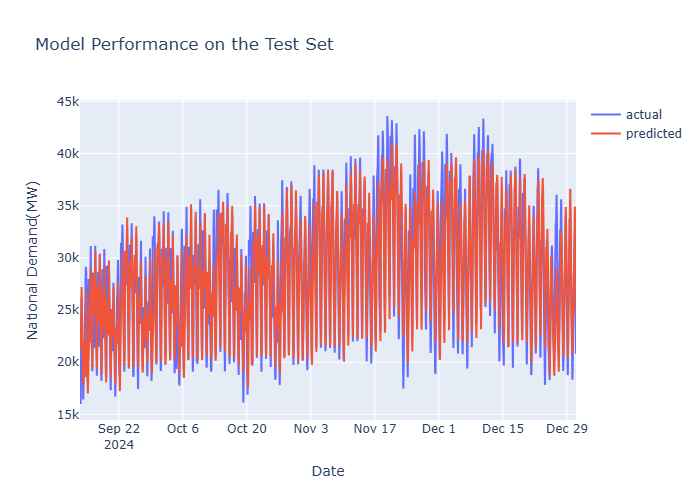

In [65]:
actual_scaled = np.concatenate([y.numpy() for _,  y in dataset_test])
predict_scaled=np.concatenate([model.predict(x,verbose=0).flatten() for  x,_ in dataset_test])

actual=target_scaler.inverse_transform(actual_scaled.reshape(-1,1)).flatten()
predicted=target_scaler.inverse_transform(predict_scaled.reshape(-1,1)).flatten()

r2=sklearn.metrics.r2_score(actual,predicted)
mae=sklearn.metrics.mean_absolute_error(actual,predicted)
rmse=sklearn.metrics.root_mean_squared_error(actual,predicted)
print('R2 score', r2)
print(f'MAE {mae:.1f}MW')
print(f'RMSE:{rmse:.1f}MW')

fig=go.Figure()
aligned_index=df_test.index[SEQUENCE_LENGTH-1:]
fig.add_trace(go.Scatter(x=aligned_index,y=actual,mode='lines',name='actual'))
fig.add_trace(go.Scatter(x=aligned_index,y=predicted,mode='lines',name='predicted'))
fig.update_layout(title='Model Performance on the Test Set',xaxis_title='Date',yaxis_title='National Demand(MW)')
Image('model_performance.png')

Chart shows the model's prediction closely tracking the actual demand across the test period. It correctly captured the daily up and down cycle and overall rise in demand heading into winter. The main gap appears at the highest peaks, such as mid November and early December, where predicted values sit slightly below the actual spikes.

RMSE being noticeably higher than MAE is a sign that the model was making a few much larger error on the highest demand days rather than being uniformly a little off everywhere.

## Model Comparison and Tuning
|#| Model Property| Validation Loss | Test R2 | Test MAE(MW) | Test RMSE(MW) | Training Time(sec) |
|---|---|---|---|---|---|---|
|1|SimpleRNN(Unit count=64)|0.089|0.796|2182|2743|435|
|2|LSTM(64)|0.089|0.84|1880|2404|488|
|**3**|**GRU-winner(64)**|**0.082**|**0.85**|**1755**|**2283**|**513**|
|4|Dropout(0.2)|"|"|"|"|"|"|
|5|Learning Rate(0.0001)|"|"|"|"|"|"|
|6|Optimizer(Adam)|"|"|"|"|"|"|"|
|7|Changed units from 64 to 128|0.076|0.79|2128|2761|607|
|8|Dropout(0.3)|0.088|0.84|1815|2399|517|
|9|Learning Rate(0.01)|0.085|0.68|2712|3421|112|
|10|Learning Rate(0.001)|0.075|0.82|1949|2563|112|
|11|Optimizer(RMSprop)|0.084|0.77|2198|2878|621|
|12|Optimizer(SGD)|0.125|0.81|1979|2585|1117|
|**13**|**Added one more GRU layer(Best Output)**|**0.080**|**0.86**|**1708**|**2200**|**773**|


##Decision Making
GRU was chosen as the base architecture after comparing against LSTM and SimpleRNN under the same condition. GRU had the lowest validation loss at 0.082 and the strongest test performance with an R2 of 0.85. SimpleRNN was clearly the weakest among them.

From there several setting were tested one at a time to see if the GRU model could be improved further. I increased the units from 64 to 128 made no real difference to performance but took noticeably lower to train so 64 units was kept. Raising dropout to 0.3 also made little difference so it was left at 0.2. A learning rate of 0.01 trained quickly but generalized poorly to the test set so it was rejected. A learning rate of 0.001 however gave a lower validation loss than the original 0.0001 while training just as fast so this was adopted going forward. Switching the optimizer to RMSprop or SGD both gave worse results than Adam along with much longer training times, so Adam was kept.

The final change tested was adding a second GRU layer, choice made to put it at end because of training time. This gave the best test result of all experiments with an R2 of 0.86 and lower error than the single layer model. This was somewhat unexpected since earlier tuning suggested the model did not benefit from extra capacity. Because of that the result is treated as promising rather than fully proven and it was a  complete worth to repeating the run.

And the patience values were chosen so the two callbacks work together rather than against each other. Early stopping was given a patience of 10 so the model had a reasonable amount of room to keep training through small dips before training was stopped completely. Reduce plateau was given a patience of 5 which is deliberately half of the early stopping value. This mean if the model stop improving the learning rate gets reduced first giving it a chance to escape a plateau before early stopping has used up its full patience and gives up. If both had the same patience the learning rate would never get a chance to help since training would already have stopped by the time it triggered.

## Sanity Check: Naive Baseline

Before trusting the model's R2, checked it against a dumb guess: Tomorrow at this time = today at this time. If the model can't beat that simple guess, its not really learning anything, it's just riding the fact that demand repeats daily. Beating this baseline is what proves the model is doing real work.


In [67]:
persistence_actual=df_test['ND'].values[FORCAST_HORIZON:]
persistence_predicted=df_test['ND'].values[:-FORCAST_HORIZON]

persistence_r2=sklearn.metrics.r2_score(persistence_actual,persistence_predicted)
print('Naive persistence R2', persistence_r2)

Naive persistence R2 0.789629158983233


## Plotting Feature Importance

In [81]:
sorted_importances=dict(sorted(importances.items(),key=lambda x:x[1],reverse=True))
fig=go.Figure()
fig.add_trace(go.Bar(x=list(sorted_importances.keys()),y=list(sorted_importances.values())))
fig.update_layout(title='Feature_Importance(drop in R2 when shuffled)',
                  xaxis_title='Feature',
                  yaxis_title='Importance(R2 drop)')
fig.show()

**Most Informative Features**
The chart showed that caleneder information mattered more to the model than any single generation feature. is_weakend caused the largest drop in R2 when shuffled, even ahead of the row demand columns themselves, which were the next important group.

## Final Discussion

**Strengths**

The model's accuracy was checked against a naive baseline being trusted.

Three architectures were compared under identical, controlled conditions(same seeds, dropout, and early stopping), rather than picking one model and assuming it was the right choice.

Data validation went beyond a basic missing value check. Checking the time index itself for gaps caught six missing timestamps tied specifically to UK daylight saving transitions.

A real data quality issue(2025 anomaly) was caught and fixed, then verified.

Sytematic hyperparameter tuning with recorded evidence.

**Limitations**

Because the chronological 80/10/10 split is based on row position rather than season, the test set spans only autumn into early winter. The reported R2 therefore reflects performance on cooler season demand specifically.

A 70/15/15 split was tested on the corrected dataset as an alternative, since it would extend the test window back to include summer. But it scored lower on R2 and not fully resolved the seasonal gap.

The model underestimates demand on the highest demand days, which is the costliest kind of error for a grid operator.

The data itself does not contain the information about temperature and weather , reason why a cold snap drive the highest demand days.

**Implications for the Business Problem**

The final model reaches an R2 of 0.86 with an average error of around 1708MW, rougly 7% of typical demand. For a grid operator this means the day ahead forecast would be meaningfully more accurate than simply assuming tomorrow looks like today, which is exactly the naive approach this project set out to beat. Even a few percent of improved accuracy at national grid scale can reduce balancing costs. The main risk that remains is on the highest demand days, where underestimating could mean scheduling slightly less generation than is actually needed.

**Recommendations**

Based on these results the model would be reasonable to use for day ahead scheduling on ordinary days, but a safety margin should be added specifically during winter periods where the model has shown it tends to underestimate. Rather than trusting the raw prediction on the coldest days, an operator would be better served treating the model's output as a lower bound during those periods until the peak demand issue is addressed.

**Deployment**

Given the current results this model is promising but not quite ready to be deployed as the sole basic for scheduling decisions. It would be reasonable to deploy as a supporting tool alongside the existing forecasting methods. Once temperature data and a more targeted loss function have been tested, it would be a stronger candidate for a larger role in real scheduling decisions.

## Future Work

Adding temperature data would likely help with peak demand. The final model's RMSE (2200MW) was noticeably higher than its MAE (1708MW), pointing to a few large errors on the cooldest, higher demand days rather than a consistent small error throughout.

MSE was suitable choice for this project, it square each error before averaging, which means a large error is punished far more than several small ones. It discourage model from making any single wrong prediction. However it still treats overestimating mainly wastes a smaller amount of capacity. This is likely part of why the model ended up underestimating demand on the highest demand days rather than being equally wrong in both directions. A custom loss function that penalizes underestimation more heavily than overestimation could address this gap.


##References

National Grid ESO (2025) *Historic demand data*. Kaggle. Available at: https://www.kaggle.com/datasets/tomfarnell/national-grid-energy-consumption-2009-2025 (Accessed: 25 August 2026)

Hochreiter, S. and Schmidhuber, J. (1997) 'Long short-term memory', *Neural Computation*, 9(8), pp. 1735-1780. Available at: https://doi.org/10.1162/neco.1997.9.8.1735

Cho, K., van Merriënboer, B., Gulcehre, C., Bahdanau, D., Bougares, F., Schwenk, H. and Bengio, Y. (2014) 'Learning phrase representations using RNN encoder-decoder for statistical machine translation', *arXiv preprint*. Available at: https://arxiv.org/abs/1406.1078

Abadi, M. et al. (2015) *TensorFlow: large-scale machine learning on heterogeneous systems*. Available at: https://www.tensorflow.org/ (Accessed: 25 August 2026).

Pedregosa, F. et al. (2011) 'Scikit-learn: machine learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825-2830. Available at: https://jmlr.org/papers/v12/pedregosa11a.html

McKinney, W. (2010) 'Data structures for statistical computing in Python', *Proceedings of the 9th Python in Science Conference*, pp. 56-61. Available at: https://conference.scipy.org/proceedings/scipy2010/mckinney.html

National Grid ESO (n.d.) *Balancing services*. Available at: https://www.nationalgrideso.com/industry-information/balancing-services (Accessed: 25 August 2026).